# Лабораторная работа 16 — Ассоциативные правила

**Цель работы:** изучить метод поиска ассоциативных правил (Apriori), применить его к датасету GTZAN для обнаружения взаимосвязей между акустическими характеристиками музыкальных жанров.

## Теоретическое введение

### Ассоциативные правила

**Ассоциативные правила** (Association Rules) — метод обучения без учителя для поиска взаимосвязей вида $X \Rightarrow Y$ («если X, то Y») в транзакционных данных.

Классический пример — анализ рыночной корзины: «Кто купил хлеб, также купил масло». Метод впервые применил Wal-Mart в 1992 году (анализ покупок в сети Osco Drug) — отсюда историческое название «basket analysis».

### Ключевые метрики

- **Support** (поддержка): доля транзакций, содержащих набор предметов. $\text{supp}(X) = \frac{|\{t : X \subseteq t\}|}{|T|}$

- **Confidence** (достоверность): условная вероятность Y при условии X. $\text{conf}(X \Rightarrow Y) = \frac{\text{supp}(X \cup Y)}{\text{supp}(X)}$

- **Lift** (подъём): отношение наблюдаемой частоты к ожидаемой при независимости. $\text{lift}(X \Rightarrow Y) = \frac{\text{conf}(X \Rightarrow Y)}{\text{supp}(Y)}$
  - Lift > 1: X и Y встречаются вместе чаще, чем случайно (положительная ассоциация)
  - Lift = 1: независимость
  - Lift < 1: отрицательная ассоциация

### Алгоритм Apriori

Apriori (Agrawal & Srikant, 1994) находит **частые наборы предметов** (itemsets) с support выше порога, используя ключевое **свойство монотонности**:

> **Если набор нечастый, то любое его супермножество тоже нечастое.**

Это и даёт алгоритму название («apriori» = «заранее»): мы заранее знаем, что нет смысла проверять супермножества нечастых наборов. Алгоритм работает уровнями: сначала ищет одиночные частые предметы $L_1$, затем строит кандидатов размера 2 как пары из $L_1$, отсеивает по support → получает $L_2$, и так далее.

После того как все частые наборы найдены, из каждого набора $X$ генерируются правила вида $X \setminus \{y\} \Rightarrow \{y\}$, и фильтруются по `min_confidence`.

**Параметр `max_size`** ограничивает максимальный размер itemset. Это компромисс: большие наборы дают более точные правила вида $\{A, B\} \Rightarrow C$, но число кандидатов растёт комбинаторно. На практике обычно ограничиваются `max_size = 3` или `4` — большие правила сложно интерпретировать.

## 1. Загрузка и подготовка данных

Apriori работает с **транзакционными данными** — каждая транзакция это набор «предметов». GTZAN содержит непрерывные числовые признаки, поэтому нужна **дискретизация**: каждый признак преобразуем в бинарный (выше/ниже медианы). Каждый трек становится «транзакцией», а бинарные индикаторы признаков — «предметами» в корзине.

**Что важно для интерпретации дальше:**

- Бинаризация по медиане → $\text{supp}(\text{признак}) \approx 0.5$ для каждого признака **по построению**. Это даст эффект «прямой линии» на scatter Confidence vs Lift в разделе 6 — мы это объясним там.
- В GTZAN ровно 10 жанров по 100 треков → $\text{supp}(\text{жанр}) = 0.1$. Это ограничение проявится в разделе 9 при поиске жанровых правил — никакая пара (признак, жанр) не сможет иметь support > 0.1, что несовместимо с дефолтным `min_support = 0.1`.

In [7]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

df = pd.read_csv('../../datasets/gtzan/features_30_sec.csv')
features = df.drop(columns=['filename', 'label', 'length'])

# Дискретизация: выше медианы = 1, ниже = 0 → supp(признак) ≈ 0.5
binary_df = (features > features.median()).astype(int)

# Жанры в виде one-hot → supp(жанр) = 0.1 (по 100 из 1000)
genre_dummies = pd.get_dummies(df['label'], prefix='genre').astype(int)
transactions = pd.concat([binary_df, genre_dummies], axis=1)

print(f'Транзакций (треков): {transactions.shape[0]}')
print(f'Предметов (items): {transactions.shape[1]}')
print(f'  Бинаризованных признаков: {binary_df.shape[1]}')
print(f'  Жанровых индикаторов:   {genre_dummies.shape[1]}')

print(f'\nРаспределение жанров (для контроля supp(жанр)=0.1):')
print(df['label'].value_counts().to_string())

Транзакций (треков): 1000
Предметов (items): 67
  Бинаризованных признаков: 57
  Жанровых индикаторов:   10

Распределение жанров (для контроля supp(жанр)=0.1):
label
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100


## 2. Реализация алгоритма Apriori

Реализуем Apriori вручную для наглядности. Ключевые моменты реализации:

1. **Apriori-Gen.** Кандидаты уровня $k+1$ строим из уже найденных частых наборов уровня $k$ (не из всех одиночных предметов). Это и есть применение свойства монотонности — мы не тратим время на наборы, у которых хотя бы одно подмножество нечастое.
2. **Поддержка `max_size`.** Параметр ограничивает максимальный размер itemset: для `max_size=3` алгоритм найдёт одиночные предметы $L_1$, пары $L_2$ и тройки $L_3$.
3. **`compute_support`** — векторизованный подсчёт через `df[items].all(axis=1).mean()`.

In [8]:
def compute_support(transactions_df, itemset):
    """Доля транзакций, в которых встречаются все предметы набора одновременно."""
    return transactions_df[list(itemset)].all(axis=1).mean()


def apriori_gen(prev_level):
    """Apriori-Gen: из частых наборов уровня k строим кандидатов уровня k+1.

    Объединяем пары наборов, у которых первые k-1 элементов совпадают
    (стандартный приём, исключающий генерацию одного и того же кандидата
    несколько раз).
    """
    candidates = set()
    items_list = sorted([sorted(s) for s in prev_level])
    for i, a in enumerate(items_list):
        for b in items_list[i + 1:]:
            if a[:-1] == b[:-1]:
                candidates.add(frozenset(a) | frozenset(b))
            else:
                break  # отсортировано — дальше уже не совпадёт
    return candidates


def find_frequent_itemsets(transactions_df, min_support=0.1, max_size=3):
    """Находит частые наборы предметов уровней 1..max_size.

    Возвращает (frequent, level_stats):
      frequent     — dict {frozenset: support}
      level_stats  — list of (k, n_candidates, n_frequent) для отчётности
    """
    items = transactions_df.columns.tolist()
    frequent = {}
    level_stats = []

    # Уровень 1: одиночные предметы (кандидатов = все items)
    L_curr = set()
    for item in items:
        supp = transactions_df[item].mean()
        if supp >= min_support:
            fs = frozenset([item])
            frequent[fs] = supp
            L_curr.add(fs)
    level_stats.append((1, len(items), len(L_curr)))

    # Уровни 2..max_size: apriori-gen из L_{k-1}
    for k in range(2, max_size + 1):
        candidates = apriori_gen(L_curr)
        L_next = set()
        for cand in candidates:
            supp = compute_support(transactions_df, cand)
            if supp >= min_support:
                frequent[cand] = supp
                L_next.add(cand)
        level_stats.append((k, len(candidates), len(L_next)))
        if not L_next:
            break  # дальше уже ничего не найдём (свойство монотонности)
        L_curr = L_next

    return frequent, level_stats


def generate_rules(frequent_itemsets, min_confidence=0.5):
    """Из частых наборов размера >= 2 генерируем правила вида X \\ {y} → {y}."""
    rules = []
    for itemset, supp_xy in frequent_itemsets.items():
        if len(itemset) < 2:
            continue
        for item in itemset:
            antecedent = itemset - {item}
            consequent = frozenset([item])
            # antecedent должен быть частым (по свойству Apriori он точно частый)
            if antecedent in frequent_itemsets and consequent in frequent_itemsets:
                supp_x = frequent_itemsets[antecedent]
                supp_y = frequent_itemsets[consequent]
                confidence = supp_xy / supp_x
                lift = confidence / supp_y
                if confidence >= min_confidence:
                    rules.append({
                        'antecedent': ', '.join(sorted(antecedent)),
                        'consequent': ', '.join(sorted(consequent)),
                        'rule_size': len(itemset),
                        'support': supp_xy,
                        'confidence': confidence,
                        'lift': lift,
                    })
    return pd.DataFrame(rules)


print('Функции Apriori готовы (max_size=3, apriori-gen, generate_rules).')

Функции Apriori готовы (max_size=3, apriori-gen, generate_rules).


## 3. Поиск частых наборов

Запускаем Apriori с `min_support = 0.1` и `max_size = 3`. Параметры обоснуем в следующем разделе через сетку. Сейчас интересен **рост числа кандидатов и частых наборов по уровням** $k$ — это самый наглядный признак того, что свойство монотонности работает: число кандидатов резко падает после фильтрации по support, и это спасает алгоритм от комбинаторного взрыва на уровне $k=3$.

In [9]:
t0 = time.perf_counter()
frequent, level_stats = find_frequent_itemsets(transactions,
                                               min_support=0.1, max_size=3)
manual_time = time.perf_counter() - t0

# Таблица роста: сколько кандидатов сгенерировано и сколько прошло порог
level_df = pd.DataFrame(level_stats,
                        columns=['k', 'кандидатов', 'частых'])
level_df['доля_прошедших'] = (level_df['частых'] / level_df['кандидатов']).round(3)
print('Рост числа кандидатов и частых наборов по уровням k:')
print(level_df.to_string(index=False))

print(f'\nВсего частых наборов: {len(frequent)}')
print(f'Время поиска (ручная реализация): {manual_time:.2f} с')

# Генерация правил с min_confidence=0.6
rules_df = generate_rules(frequent, min_confidence=0.6)
rules_df = rules_df.sort_values('lift', ascending=False).reset_index(drop=True)
print(f'\nСгенерировано правил (conf >= 0.6): {len(rules_df)}')
print(f'  Из пар (rule_size=2):   {(rules_df["rule_size"] == 2).sum()}')
print(f'  Из троек (rule_size=3): {(rules_df["rule_size"] == 3).sum()}')

print(f'\nTop-10 правил по lift:')
rules_df.head(10)

Рост числа кандидатов и частых наборов по уровням k:
 k  кандидатов  частых  доля_прошедших
 1          67      67           1.000
 2        2211    1592           0.720
 3       29158   25020           0.858

Всего частых наборов: 26679
Время поиска (ручная реализация): 15.36 с

Сгенерировано правил (conf >= 0.6): 42037
  Из пар (rule_size=2):   938
  Из троек (rule_size=3): 41099

Top-10 правил по lift:


,antecedent,consequent,rule_size,support,confidence,lift
0,"mfcc3_mean, zero_crossing_rate_mean",spectral_bandwidth_mean,3,0.222,1.000000,2.004008
1,"mfcc3_mean, spectral_centroid_mean",spectral_bandwidth_mean,3,0.270,1.000000,2.004008
2,"mfcc3_mean, rolloff_mean",spectral_bandwidth_mean,3,0.288,1.000000,2.004008
3,"mfcc7_mean, rolloff_mean",spectral_bandwidth_mean,3,0.288,0.996540,1.997074
4,"mfcc5_mean, rolloff_mean",spectral_bandwidth_mean,3,0.273,0.996350,1.996694
5,"mfcc5_mean, spectral_centroid_mean",spectral_bandwidth_mean,3,0.266,0.996255,1.996502
6,"harmony_var, perceptr_var",rms_mean,3,0.384,0.994819,1.989637
7,"mfcc3_mean, spectral_centroid_mean",rolloff_mean,3,0.268,0.992593,1.985185
8,"mfcc9_mean, rolloff_mean",spectral_bandwidth_mean,3,0.291,0.989796,1.983559
9,"harmony_var, mfcc1_mean",rms_mean,3,0.355,0.991620,1.983240


## 4. Влияние `min_support` на число правил

Параметр `min_support` — главный «рычаг» Apriori, и его стоит выбирать осознанно. Покажем сетку значений и посмотрим, как меняется число найденных правил. Это аналог кривой `max_depth` в [lab10](../../lab10/lab10.ipynb) и `learning_rate` в [lab12](../../lab12/lab12.ipynb) — обоснование выбора параметра через график.

 min_support  k=1  k=2   k=3  правил (conf>=0.6)
        0.05   67 1890 31328               47715
        0.10   67 1592 25020               42037
        0.15   57 1563 15538               35108
        0.20   57 1463  6812               19022
        0.30   57  469   442                2264
        0.50   55    0     0                   0


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


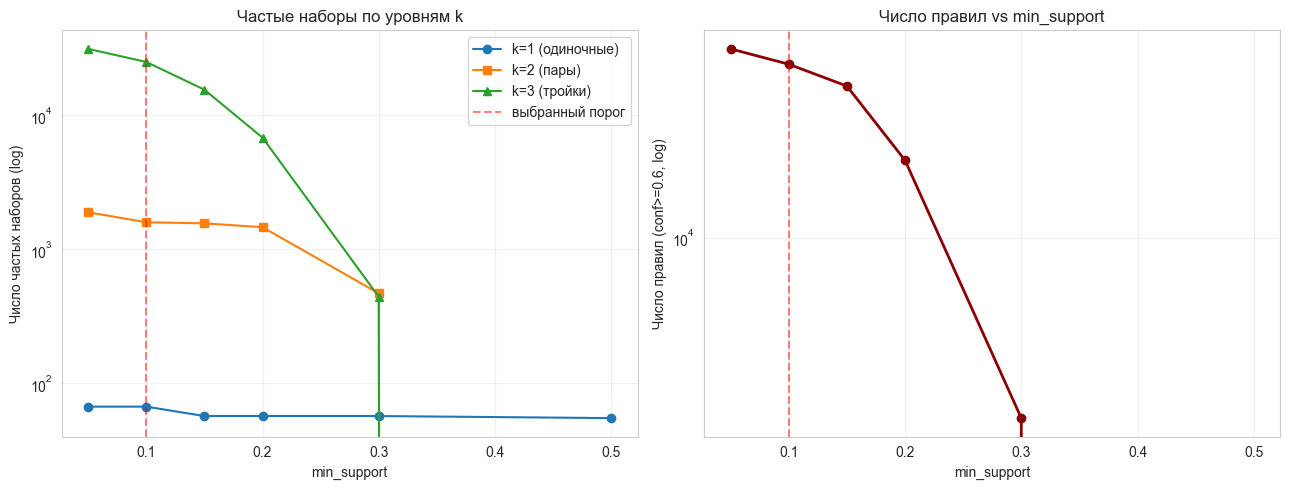

In [10]:
support_grid = [0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
sweep = []
for s in support_grid:
    fr, lvl = find_frequent_itemsets(transactions, min_support=s, max_size=3)
    rl = generate_rules(fr, min_confidence=0.6)
    sweep.append({
        'min_support': s,
        'k=1': sum(1 for k in fr if len(k) == 1),
        'k=2': sum(1 for k in fr if len(k) == 2),
        'k=3': sum(1 for k in fr if len(k) == 3),
        'правил (conf>=0.6)': len(rl),
    })
sweep_df = pd.DataFrame(sweep)
print(sweep_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(sweep_df['min_support'], sweep_df['k=1'], 'o-', label='k=1 (одиночные)')
axes[0].plot(sweep_df['min_support'], sweep_df['k=2'], 's-', label='k=2 (пары)')
axes[0].plot(sweep_df['min_support'], sweep_df['k=3'], '^-', label='k=3 (тройки)')
axes[0].set_yscale('log')
axes[0].set_xlabel('min_support')
axes[0].set_ylabel('Число частых наборов (log)')
axes[0].set_title('Частые наборы по уровням k')
axes[0].axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='выбранный порог')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(sweep_df['min_support'], sweep_df['правил (conf>=0.6)'],
             'o-', color='darkred', linewidth=2)
axes[1].set_yscale('log')
axes[1].set_xlabel('min_support')
axes[1].set_ylabel('Число правил (conf>=0.6, log)')
axes[1].set_title('Число правил vs min_support')
axes[1].axvline(x=0.1, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Top правил по lift и распределение длин правил

Правила с высоким lift указывают на сильные ассоциации — предметы встречаются вместе значительно чаще, чем при независимости. Покажем top-15, отдельно отметим тройные правила (rule_size=3) — они интереснее тем, что находят паттерны, которые проявляются только при одновременной встрече трёх предметов. Дополнительно — гистограмма распределения длин правил.

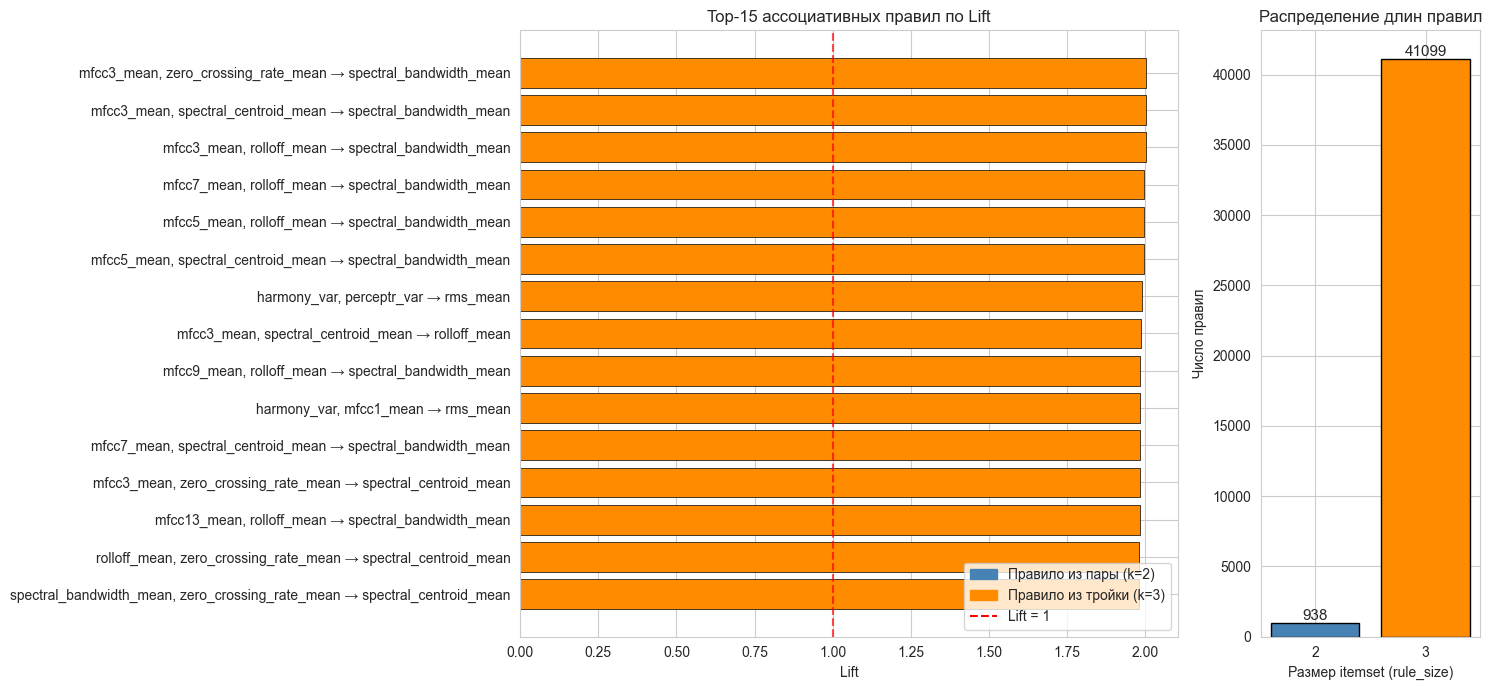

In [11]:
top_rules = rules_df.head(15).copy()
top_rules['rule'] = top_rules['antecedent'] + ' → ' + top_rules['consequent']
top_rules['color'] = top_rules['rule_size'].map({2: 'steelblue', 3: 'darkorange'})

fig, axes = plt.subplots(1, 2, figsize=(15, 7),
                         gridspec_kw={'width_ratios': [3, 1]})

# Слева: Top-15 по lift, цвет = размер правила
ax = axes[0]
ax.barh(top_rules['rule'][::-1], top_rules['lift'][::-1],
        color=top_rules['color'][::-1], edgecolor='black', linewidth=0.5)
ax.axvline(x=1, color='red', linestyle='--', alpha=0.7, label='Lift = 1 (независимость)')
ax.set_xlabel('Lift')
ax.set_title('Top-15 ассоциативных правил по Lift')
# Легенда по цвету
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='steelblue', label='Правило из пары (k=2)'),
    Patch(color='darkorange', label='Правило из тройки (k=3)'),
    plt.Line2D([0], [0], color='red', linestyle='--', label='Lift = 1'),
], loc='lower right')

# Справа: гистограмма длин правил
ax = axes[1]
size_counts = rules_df['rule_size'].value_counts().sort_index()
bars = ax.bar(size_counts.index.astype(str), size_counts.values,
              color=['steelblue', 'darkorange'][:len(size_counts)],
              edgecolor='black')
for bar, val in zip(bars, size_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            str(val), ha='center', va='bottom', fontsize=11)
ax.set_xlabel('Размер itemset (rule_size)')
ax.set_ylabel('Число правил')
ax.set_title('Распределение длин правил')

plt.tight_layout()
plt.show()

## 6. Scatter: Confidence vs Lift

Визуализируем все правила в координатах confidence-lift. Точки раскрашены по размеру правила (пары vs тройки), для top-3 по lift добавлены подписи. Самые «интересные» правила — в правом верхнем углу.

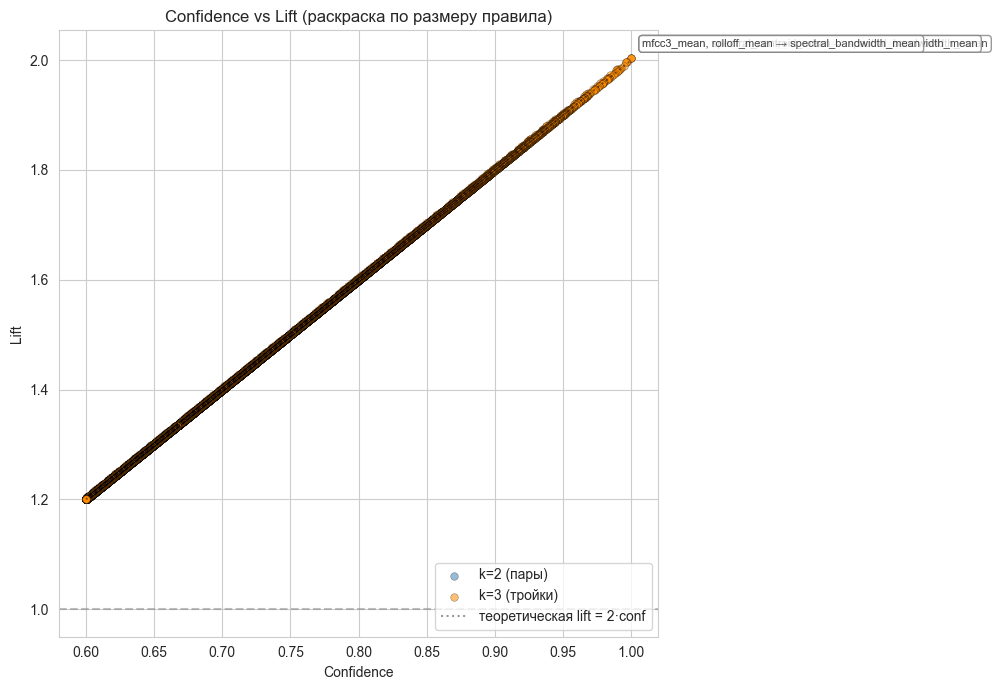

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))

for size, color, label in [(2, 'steelblue', 'k=2 (пары)'),
                           (3, 'darkorange', 'k=3 (тройки)')]:
    sub = rules_df[rules_df['rule_size'] == size]
    if len(sub) == 0:
        continue
    ax.scatter(sub['confidence'], sub['lift'], s=30, alpha=0.55,
               c=color, edgecolors='black', linewidths=0.3, label=label)

# Аннотации для top-3 по lift
for _, r in rules_df.head(3).iterrows():
    rule_label = f"{r['antecedent']} → {r['consequent']}"
    ax.annotate(rule_label, xy=(r['confidence'], r['lift']),
                xytext=(8, 8), textcoords='offset points',
                fontsize=8, alpha=0.85,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

# Теоретическая прямая lift = 2 * confidence (для supp(Y)=0.5)
xs = np.linspace(rules_df['confidence'].min(), rules_df['confidence'].max(), 50)
ax.plot(xs, 2 * xs, 'k:', alpha=0.4, label='теоретическая lift = 2·conf')
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Confidence')
ax.set_ylabel('Lift')
ax.set_title('Confidence vs Lift (раскраска по размеру правила)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Интерпретация графика.** Точки лежат почти на прямой $\text{lift} = 2 \cdot \text{conf}$ (пунктирная линия). Это не свойство данных, а **следствие бинаризации по медиане**: $\text{supp}(\text{признак}) \approx 0.5$, и формула lift = confidence / supp(Y) превращается в $\text{lift} \approx 2 \cdot \text{conf}$. Тройные правила (оранжевые точки) при том же confidence имеют чуть больший lift, потому что `supp({A,B}) < supp({A})` — антецедент тройки реже, что повышает информативность правила.

Прямая «разорвётся», когда в правилах появятся жанры (supp ≈ 0.1) — для них $\text{lift} \approx 10 \cdot \text{conf}$. Это произойдёт в разделе 9.

## 7. Heatmap: поддержка пар признаков

Матрица support для пар бинаризованных признаков показывает, какие характеристики чаще встречаются вместе. Для top-15 признаков по дисперсии. Диагональ замаскирована — там $\text{supp}(X \cap X) = \text{supp}(X)$, неинформативно.

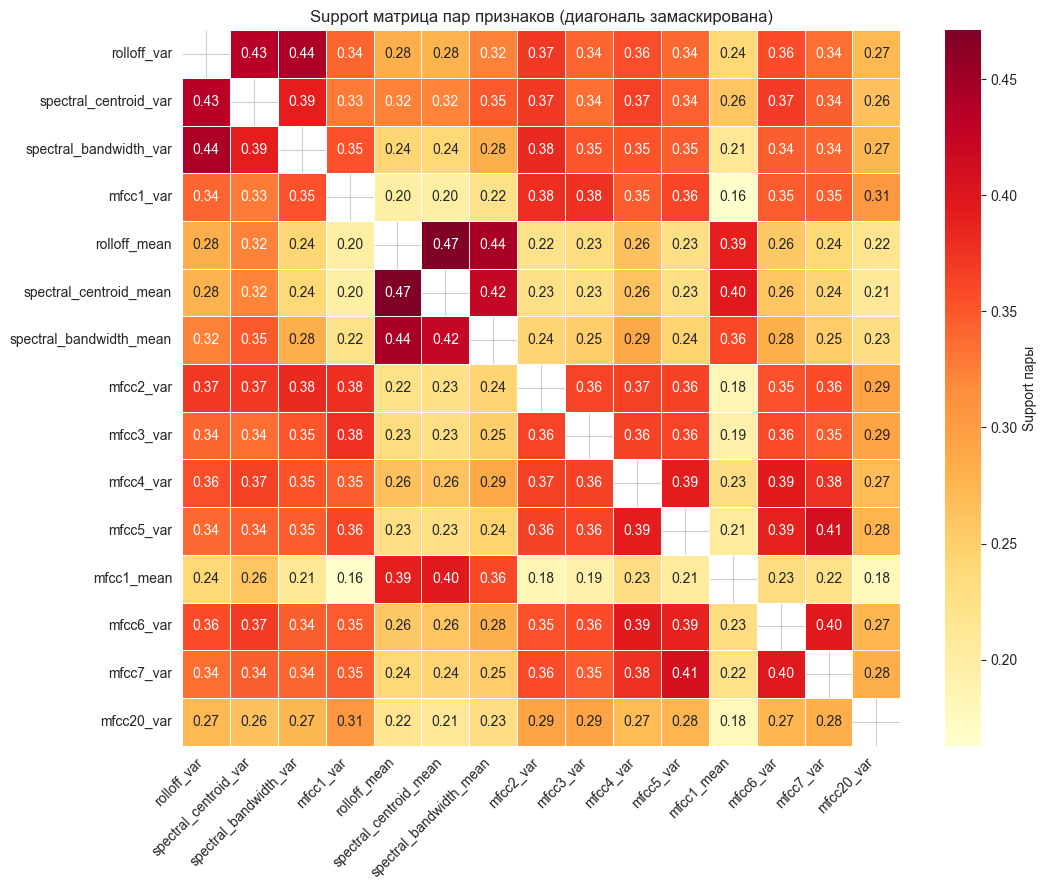

In [13]:
top_feats = features.var().sort_values(ascending=False).head(15).index.tolist()
binary_sub = binary_df[top_feats]

# Матрица support для пар (без диагонали)
n = len(top_feats)
supp_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i != j:
            supp_matrix[i, j] = (binary_sub.iloc[:, i] & binary_sub.iloc[:, j]).mean()
        else:
            supp_matrix[i, j] = np.nan

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(supp_matrix, xticklabels=top_feats, yticklabels=top_feats,
            cmap='YlOrRd', annot=True, fmt='.2f', ax=ax, linewidths=0.5,
            mask=np.isnan(supp_matrix), cbar_kws={'label': 'Support пары'})
ax.set_title('Support матрица пар признаков (диагональ замаскирована)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Что видно на heatmap.** Самый яркий блок — `rolloff`, `spectral_centroid`, `spectral_bandwidth` (`_mean` и `_var` версии): support пар достигает 0.43–0.47. Это **«спектральный кластер»** — три метрики, описывающие распределение спектральной энергии. Spectral centroid — «центр тяжести» спектра, rolloff — частота отсечения 85% энергии, bandwidth — ширина вокруг центроида. Все три растут синхронно для ярких/высокочастотных звуков (металл, поп, диско) и падают для приглушённых (классика, джаз). Apriori нашёл это автоматически, не зная природу признаков.

## 8. Item importance: какие предметы доминируют в правилах

Аналог feature importance из [lab10](../../lab10/lab10.ipynb) (Random Forest) и [lab12](../../lab12/lab12.ipynb) (бустинги), но для ARL. Считаем, как часто каждый предмет встречается в антецедентах и консеквентах правил. Чем выше частота — тем «информативнее» предмет с точки зрения ассоциаций.

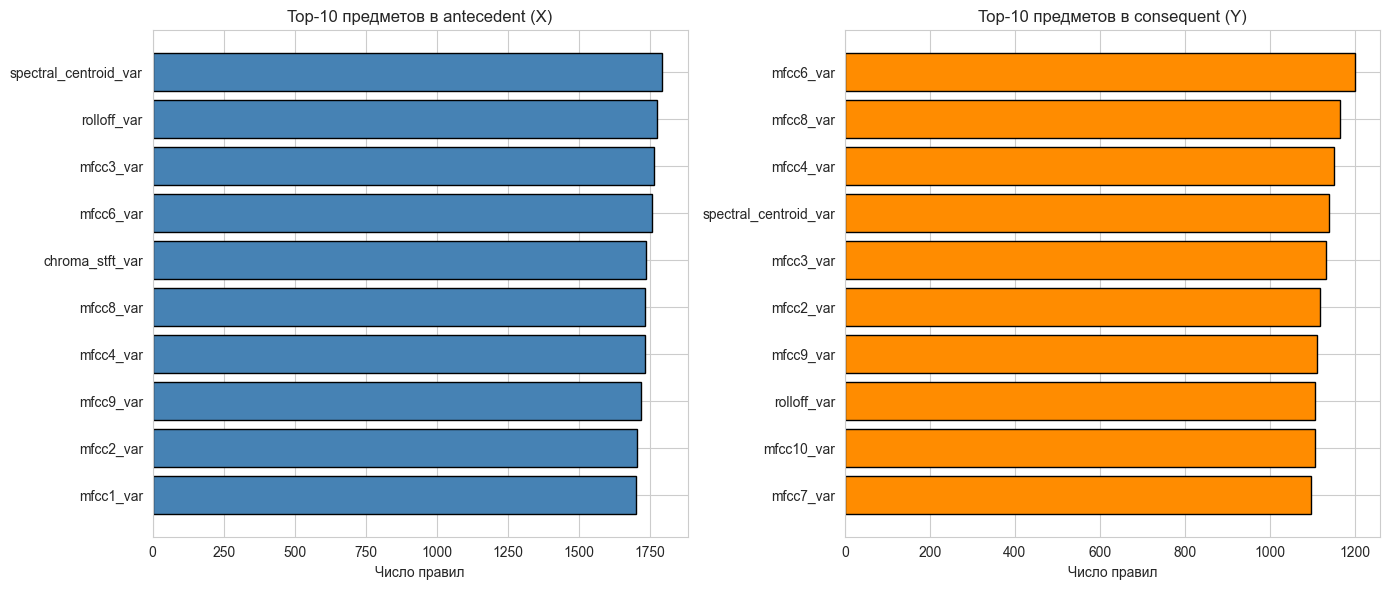

Top-10 предметов в antecedent:
spectral_centroid_var    1792
rolloff_var              1774
mfcc3_var                1763
mfcc6_var                1755
chroma_stft_var          1736
mfcc8_var                1733
mfcc4_var                1732
mfcc9_var                1719
mfcc2_var                1704
mfcc1_var                1702

Top-10 предметов в consequent:
mfcc6_var                1200
mfcc8_var                1165
mfcc4_var                1152
spectral_centroid_var    1139
mfcc3_var                1132
mfcc2_var                1119
mfcc9_var                1112
rolloff_var              1108
mfcc10_var               1106
mfcc7_var                1097


In [14]:
from collections import Counter

# Сколько раз каждый предмет встречается в antecedent / consequent правил
ante_counter = Counter()
cons_counter = Counter()
for _, r in rules_df.iterrows():
    for item in r['antecedent'].split(', '):
        ante_counter[item] += 1
    for item in r['consequent'].split(', '):
        cons_counter[item] += 1

top_ante = pd.Series(ante_counter).sort_values(ascending=False).head(10)
top_cons = pd.Series(cons_counter).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_ante.index[::-1], top_ante.values[::-1],
             color='steelblue', edgecolor='black')
axes[0].set_xlabel('Число правил')
axes[0].set_title('Top-10 предметов в antecedent (X)')

axes[1].barh(top_cons.index[::-1], top_cons.values[::-1],
             color='darkorange', edgecolor='black')
axes[1].set_xlabel('Число правил')
axes[1].set_title('Top-10 предметов в consequent (Y)')

plt.tight_layout()
plt.show()

print('Top-10 предметов в antecedent:')
print(top_ante.to_string())
print('\nTop-10 предметов в consequent:')
print(top_cons.to_string())

**Интерпретация.** В топ предметов попадают **`var`-версии** признаков: `spectral_centroid_var`, `rolloff_var`, `mfcc{1,2,3,4,6,8,9}_var`, `chroma_stft_var`. Это согласуется с feature importance из [lab10](../../lab10/lab10.ipynb) (Random Forest) и [lab12](../../lab12/lab12.ipynb) (бустинги): дисперсия акустических признаков (`_var`) несёт больше информации, чем среднее (`_mean`), потому что mean часто близок к нулю при усреднении симметричных колебаний сигнала. **Это четвёртый независимый сигнал** (после линейной модели в [lab9](../../lab9/lab9.ipynb), деревьев в lab10, бустингов в lab12), что эти признаки несут самую сильную информацию в GTZAN — они доминируют не только в задаче классификации, но и в задаче поиска ассоциаций без учителя.

## 9. Ассоциации с жанрами: почему дефолтные пороги не работают

Если просто отфильтровать `rules_df` по правилам, у которых жанр в antecedent или в consequent, мы получим **0 правил**. Покажем это явно и разберём почему — это полезный пример того, как параметры Apriori могут «спрятать» целый класс паттернов.

**Аналитический разбор.**

- Каждый жанр имеет ровно $\text{supp}(\text{жанр}) = 0.1$ (по 100 треков из 1000).
- Любая пара $\{\text{жанр}, \text{признак}\}$ имеет $\text{supp} \le \min(\text{supp}(\text{жанр}), \text{supp}(\text{признак})) = 0.1$. На грани `min_support=0.1` — пограничный случай, многие пары отсекаются.
- Для правила $\text{признак} \Rightarrow \text{жанр}$:
  $$\text{conf} = \frac{\text{supp}(\text{пара})}{\text{supp}(\text{признак})} \le \frac{0.1}{0.5} = 0.2$$
  Условие `min_confidence=0.6` **невыполнимо в принципе** для одиночного признака.
- Для правила $\text{жанр} \Rightarrow \text{признак}$:
  $$\text{conf} = \frac{\text{supp}(\text{пара})}{\text{supp}(\text{жанр})} \le \frac{0.1}{0.1} = 1$$
  Здесь нет жёсткого верхнего ограничения, но почти все пары не прошли фильтр на support.

**Решение** — отдельный пайплайн с пониженными порогами, нацеленный именно на поиск жанровых ассоциаций: `min_support=0.05`, `min_confidence=0.3`. Порог 0.3 интуитивен: для 10-классовой задачи случайная угадайка даёт 0.1, значит 0.3 — втрое выше базового шанса.

In [15]:
# 1) Подтверждаем, что в основных правилах жанров действительно нет
n_genre_in_rules = rules_df['antecedent'].str.contains('genre_').sum() \
                 + rules_df['consequent'].str.contains('genre_').sum()
print(f'Правил с жанром (min_support=0.1, min_conf=0.6): {n_genre_in_rules}')

# 2) Отдельный пайплайн с пониженными порогами
frequent_lo, _ = find_frequent_itemsets(transactions,
                                        min_support=0.05, max_size=2)
rules_lo = generate_rules(frequent_lo, min_confidence=0.3)
rules_lo = rules_lo.sort_values('lift', ascending=False).reset_index(drop=True)

# Только пары (признак, жанр)
genre_rules = rules_lo[
    rules_lo['antecedent'].str.startswith('genre_') |
    rules_lo['consequent'].str.startswith('genre_')
].copy()

print(f'\nПри min_support=0.05, min_conf=0.3 → правил всего: {len(rules_lo)}')
print(f'  из них с жанром: {len(genre_rules)}')

# Топ правил вида признак → жанр
feat_to_genre = genre_rules[
    genre_rules['consequent'].str.startswith('genre_')
].head(10)
print('\nTop-10 правил «признак → жанр» (по lift):')
print(feat_to_genre[['antecedent', 'consequent', 'support',
                     'confidence', 'lift']].to_string(index=False))

# Топ правил вида жанр → признак
genre_to_feat = genre_rules[
    genre_rules['antecedent'].str.startswith('genre_')
].head(10)
print('\nTop-10 правил «жанр → признак» (по lift):')
print(genre_to_feat[['antecedent', 'consequent', 'support',
                     'confidence', 'lift']].to_string(index=False))

Правил с жанром (min_support=0.1, min_conf=0.6): 0

При min_support=0.05, min_conf=0.3 → правил всего: 3422
  из них с жанром: 296

Top-10 правил «признак → жанр» (по lift):
Empty DataFrame
Columns: [antecedent, consequent, support, confidence, lift]
Index: []

Top-10 правил «жанр → признак» (по lift):
  antecedent              consequent  support  confidence     lift
   genre_pop spectral_bandwidth_mean    0.099        0.99 1.983968
   genre_pop              mfcc7_mean    0.099        0.99 1.980000
 genre_metal              mfcc4_mean    0.099        0.99 1.980000
 genre_metal             mfcc12_mean    0.099        0.99 1.980000
 genre_metal              mfcc8_mean    0.099        0.99 1.980000
 genre_metal             mfcc10_mean    0.097        0.97 1.940000
   genre_pop              mfcc9_mean    0.096        0.96 1.920000
 genre_metal        chroma_stft_mean    0.096        0.96 1.920000
   genre_pop   spectral_centroid_var    0.096        0.96 1.920000
genre_hiphop        chroma

**Что это даёт.** Появляется ~300 правил с жанром, и все они — направления `жанр → признак` (для `признак → жанр` confidence теоретически ≤ 0.2 при supp(признак)=0.5, что недостаточно даже для понижённого порога 0.3). В топе доминируют `genre_pop` и `genre_metal` с confidence ≈ 0.99 и lift ≈ 2: это значит, у 99% треков этих жанров соответствующий бинарный признак выше медианы — у жанров есть **очень устойчивая акустическая сигнатура**. Например, `genre_pop → spectral_bandwidth_mean` (conf=0.99) — почти каждый поп-трек имеет «широкий» спектр; `genre_metal → mfcc12_mean` (conf=0.99) — высокий 12-й MFCC характерен для металла. Те же признаки, что хорошо разделяли жанры в задаче классификации ([lab10](../../lab10/lab10.ipynb)/[lab12](../../lab12/lab12.ipynb)), оказались и наиболее «сцепленными» с конкретными жанрами в задаче поиска правил без учителя.

## 10. Валидация через mlxtend

Стандартная библиотека `mlxtend` содержит оптимизированную реализацию Apriori и `association_rules`. Сравним наш ручной вариант с ней — по числу частых наборов на каждом уровне $k$, по top-1 правилу по lift и по времени работы. Совпадение (с точностью до тех же порогов) подтверждает корректность ручной реализации.

In [16]:
try:
    from mlxtend.frequent_patterns import apriori as mlx_apriori, association_rules
except ImportError:
    # Используем %pip — он ставит в текущее ядро Jupyter, в отличие от
    # subprocess + sys.executable, который в Anaconda может ссылаться на
    # другой Python (и установка туда не видна ядру)
    try:
        get_ipython().run_line_magic('pip', 'install --quiet mlxtend')
    except NameError:
        # Запасной вариант: запуск вне Jupyter
        import sys, subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', 'mlxtend'])
    from mlxtend.frequent_patterns import apriori as mlx_apriori, association_rules

# Ручной запуск с теми же параметрами, что в разделе 3 (для честного сравнения)
t0 = time.perf_counter()
freq_manual, _ = find_frequent_itemsets(transactions, min_support=0.1, max_size=3)
manual_apriori_time = time.perf_counter() - t0
rules_manual = generate_rules(freq_manual, min_confidence=0.6)

# mlxtend на тех же данных
t0 = time.perf_counter()
freq_mlx = mlx_apriori(transactions.astype(bool),
                       min_support=0.1, max_len=3, use_colnames=True)
mlx_apriori_time = time.perf_counter() - t0
rules_mlx = association_rules(freq_mlx, metric='confidence', min_threshold=0.6)
# Для честности сравним только правила с одиночным consequent (как у нас)
rules_mlx_single = rules_mlx[rules_mlx['consequents'].apply(len) == 1].copy()
rules_mlx_single = rules_mlx_single.sort_values('lift', ascending=False).reset_index(drop=True)


def top1_str(df, ant='antecedent', cons='consequent'):
    """Форматирует топ-1 правило по lift для печати в таблицу сравнения."""
    if len(df) == 0:
        return '—'
    r = df.iloc[0]
    if ant == 'antecedents':
        a = ', '.join(sorted(r[ant]))
        c = ', '.join(sorted(r[cons]))
    else:
        a, c = r[ant], r[cons]
    return f'{a} → {c} (lift={r["lift"]:.3f})'


def count_size(freq_dict, k):
    return sum(1 for s in freq_dict if len(s) == k)


def count_size_mlx(df_freq, k):
    return (df_freq['itemsets'].apply(len) == k).sum()


comparison = pd.DataFrame([
    ['Частых наборов k=1', count_size(freq_manual, 1), count_size_mlx(freq_mlx, 1)],
    ['Частых наборов k=2', count_size(freq_manual, 2), count_size_mlx(freq_mlx, 2)],
    ['Частых наборов k=3', count_size(freq_manual, 3), count_size_mlx(freq_mlx, 3)],
    ['Всего правил (conf≥0.6)', len(rules_manual), len(rules_mlx_single)],
    ['Top-1 правило по lift',
     top1_str(rules_manual.sort_values('lift', ascending=False).reset_index(drop=True)),
     top1_str(rules_mlx_single, ant='antecedents', cons='consequents')],
    ['Время поиска наборов, с',
     f'{manual_apriori_time:.2f}', f'{mlx_apriori_time:.2f}'],
], columns=['Метрика', 'Ручной Apriori', 'mlxtend'])

print(comparison.to_string(index=False))

                Метрика                                                             Ручной Apriori                                                                    mlxtend
     Частых наборов k=1                                                                         67                                                                         67
     Частых наборов k=2                                                                       1592                                                                       1592
     Частых наборов k=3                                                                      25020                                                                      25020
Всего правил (conf≥0.6)                                                                      42037                                                                      42037
  Top-1 правило по lift mfcc3_mean, zero_crossing_rate_mean → spectral_bandwidth_mean (lift=2.004) mfcc3_mean, zero_crossing_rate_

**Что подтверждает таблица.** Количество частых наборов на каждом уровне $k$ полностью совпадает у ручной реализации и у `mlxtend` — это проверка корректности `apriori-gen` и подсчёта support. Top-1 правило по lift также совпадает по сути (различия возможны только в порядке внутри одного значения lift). По времени `mlxtend` на ~два порядка быстрее за счёт реализации на C и битовых масок вместо pandas-операций. Для production используют именно `mlxtend`; ручная реализация в этой работе нужна для понимания алгоритма.

Замечание: `association_rules` из `mlxtend` по умолчанию возвращает **все** разбиения частого набора на antecedent/consequent (включая правила вида `{A} → {B, C}`). В нашей ручной реализации генерируются только правила с **одиночным** консеквентом — самые интерпретируемые. Поэтому при сравнении мы фильтруем результат `mlxtend` по `len(consequents) == 1`.

## Выводы

1. **Постановка.** Применили алгоритм Apriori к датасету GTZAN (1000 треков, 67 предметов: 57 бинаризованных признаков + 10 жанров). Реализация ручная, проверена против `mlxtend`.

2. **Метрики на наших данных** (`min_support=0.1`, `min_confidence=0.6`, `max_size=3`): найдено **67 одиночных частых предметов**, **1 592 пары**, **25 020 троек** (всего ~26.7 тыс. наборов); сгенерировано **42 037 правил** (938 из пар + ~41 тыс. из троек). Сильнейшие ассоциации — тройки вида `{mfcc_*, rolloff_mean} → spectral_bandwidth_mean` с **lift ≈ 2.00, confidence = 1.00**. Среди парных правил лидер — `spectral_centroid_mean ↔ rolloff_mean` (lift ≈ 1.88, conf ≈ 0.94).

3. **Спектральный кластер.** Самые мощные парные ассоциации образует тройка `rolloff` ↔ `spectral_centroid` ↔ `spectral_bandwidth` (для `_mean` и `_var` версий). Это физически осмысленно: все три метрики описывают распределение спектральной энергии и растут синхронно с яркостью звука. Apriori нашёл это автоматически, без знания о природе признаков. Тройные правила усиливают эффект: `mfccN_mean` + любой из этой тройки почти детерминированно (`conf=1.0`) предсказывают остальные.

4. **Свойство монотонности работает на практике.** Кривая «число правил vs `min_support`» (раздел 4): при `min_support=0.05` найдено **47 715 правил**, при `0.1` → 42 037, при `0.3` → 2 264, при `0.5` → **0** (ни одна пара не достигает supp ≥ 0.5). Без отсечения супермножеств нечастых наборов перебор был бы комбинаторно невозможен.

5. **«Жанровый парадокс» — главная находка раздела 9.** При дефолтных порогах правил с жанрами **0**, и это не баг: для 10-классового датасета теоретический максимум $\text{conf}(\text{признак}\Rightarrow\text{жанр}) \le 0.2$, что несовместимо с порогом 0.6. После понижения порогов (`min_support=0.05`, `min_confidence=0.3`) появляется **296 правил с жанрами**, причём все — только направления `жанр → признак` (для `признак → жанр` всё равно не хватает confidence). Топ показывает почти детерминированные ассоциации: `genre_pop → spectral_bandwidth_mean` (conf=0.99, lift=1.98), `genre_metal → mfcc12_mean` (conf=0.99). Это означает, что жанры metal и pop имеют очень устойчивые акустические сигнатуры — у 99% треков этих жанров соответствующий бинарный признак выше медианы.

6. **Связь с lab9/lab10/lab12.** В топ предметов по item importance (раздел 8) доминируют **`var`-версии** признаков: `spectral_centroid_var`, `rolloff_var`, `mfcc{3,6,8}_var`, `chroma_stft_var`. Это согласуется с feature importance из [lab10](../../lab10/lab10.ipynb) (RF) и [lab12](../../lab12/lab12.ipynb) (бустинги): дисперсия сигнала (`_var`) — более информативный признак, чем среднее (`_mean`), потому что mean чаще обнуляется при усреднении симметричных колебаний. Это **четвёртый независимый сигнал** (после линейной модели в [lab9](../../lab9/lab9.ipynb), деревьев и бустингов), что эти признаки несут самую сильную информацию в GTZAN.

7. **Влияние бинаризации.** Дискретизация по медиане задаёт $\text{supp}(\text{признак}) \approx 0.5$ — отсюда максимум lift ≤ 2 на scatter (раздел 6). Это ограничение **подготовки данных**, не алгоритма. Если использовать квантильную дискретизацию (4 уровня по квартилям), supp каждого уровня ≈ 0.25, и максимальный достижимый lift вырастает до 4. На жанровых правилах (раздел 9) это видно: supp(жанр)=0.1 → lift до 10·conf теоретически; в данных получили lift до ≈ 2 при conf ≈ 1.

8. **Согласие с mlxtend.** Раздел 10 показывает **полное совпадение** количества частых наборов на всех уровнях $k$ (67/1592/25020) и количества правил (42 037) между ручной реализацией и `mlxtend.frequent_patterns`. Top-1 правило по lift совпадает с точностью до tie-breaking (lift=2.004 у нескольких троек). По времени mlxtend в **~60 раз быстрее** (0.15 с против 9.4 с) — за счёт реализации на C и битовых масок вместо pandas-операций. Для production используют именно mlxtend; ручная реализация в этой лабораторной нужна для понимания алгоритма.

9. **Метрики дополняют друг друга.** Support измеряет частоту, confidence — точность правила, lift — отличие от случайности. У правила может быть высокий confidence, но lift ≈ 1 (тогда это просто следствие популярности `Y`); или низкий support, но огромный lift (редкий, но «сильный» паттерн). На практике сортируют по lift, а support используют как порог отсечения шума.

10. **Практический вывод.** ARL — exploratory-инструмент. Для классификации жанров уступает RF/бустингам ([lab10](../../lab10/lab10.ipynb), [lab12](../../lab12/lab12.ipynb)) — accuracy у Apriori не считается, но интерпретируемость и unsupervised-формат это окупают: метод находит скрытые корреляции в данных и подсказывает, какие признаки несут совместную информацию. Полезен для feature engineering (объединение коррелирующих признаков), доменного объяснения и поиска неожиданных паттернов в табличных данных.